# 03 · Learning curves and uncertainty

Reads only `results/03_learning_curves/` and `results/03_uncertainty/` (written by
`experiments/03_*.py`); nothing is fitted and no API is called here. XGBoost learning curves and
uncertainty baselines were run off-Mac; `machines.json` records which machine ran each result.
Every number is printed from the result files.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

LC = Path("../results/03_learning_curves")
UNC = Path("../results/03_uncertainty")
FIG = UNC / "figures"
SIZES = ["100", "300", "1000", "3000", "10000", "full"]
curves = pd.read_csv(LC / "curves.csv", dtype={"n_label": str})
cal = pd.read_csv(UNC / "calibration.csv")

## 1. Learning curves (grouped splits 0-4, nested training subsets, fixed test sets)

n_label                     100    300   1000   3000  10000   full
features    model                                                 
composition tabpfn        17.53  15.34  13.10  11.08   9.33   8.94
            xgb_hamidieh  18.17  15.49  13.68  11.96  10.40  10.01
            xgb_tuned     19.64  16.61  14.14  12.36  10.35   9.82
engineered  tabpfn        18.59  15.15  12.95  11.18   9.44   9.06
            xgb_hamidieh  19.41  16.31  13.86  12.11  10.15   9.77
            xgb_tuned     20.32  16.94  14.19  12.00  10.09   9.70

,features,n_label,b,b_variant,n_splits,mean_diff,std_diff,a_better_splits,b_better_splits
0,composition,100,xgb_tuned,xgb_tuned,5,-2.117,1.138,5,0
1,composition,100,xgb_hamidieh,xgb_hamidieh,5,-0.645,0.668,4,1
2,composition,100,xgb_best,xgb_hamidieh,5,-0.645,0.668,4,1
3,composition,1000,xgb_tuned,xgb_tuned,5,-1.044,0.195,5,0
4,composition,1000,xgb_hamidieh,xgb_hamidieh,5,-0.576,0.249,5,0
5,composition,1000,xgb_best,xgb_hamidieh,5,-0.576,0.249,5,0
6,composition,10000,xgb_tuned,xgb_tuned,5,-1.023,0.168,5,0
7,composition,10000,xgb_hamidieh,xgb_hamidieh,5,-1.076,0.067,5,0
8,composition,10000,xgb_best,xgb_tuned,5,-1.023,0.168,5,0
9,composition,300,xgb_tuned,xgb_tuned,5,-1.266,1.054,4,1


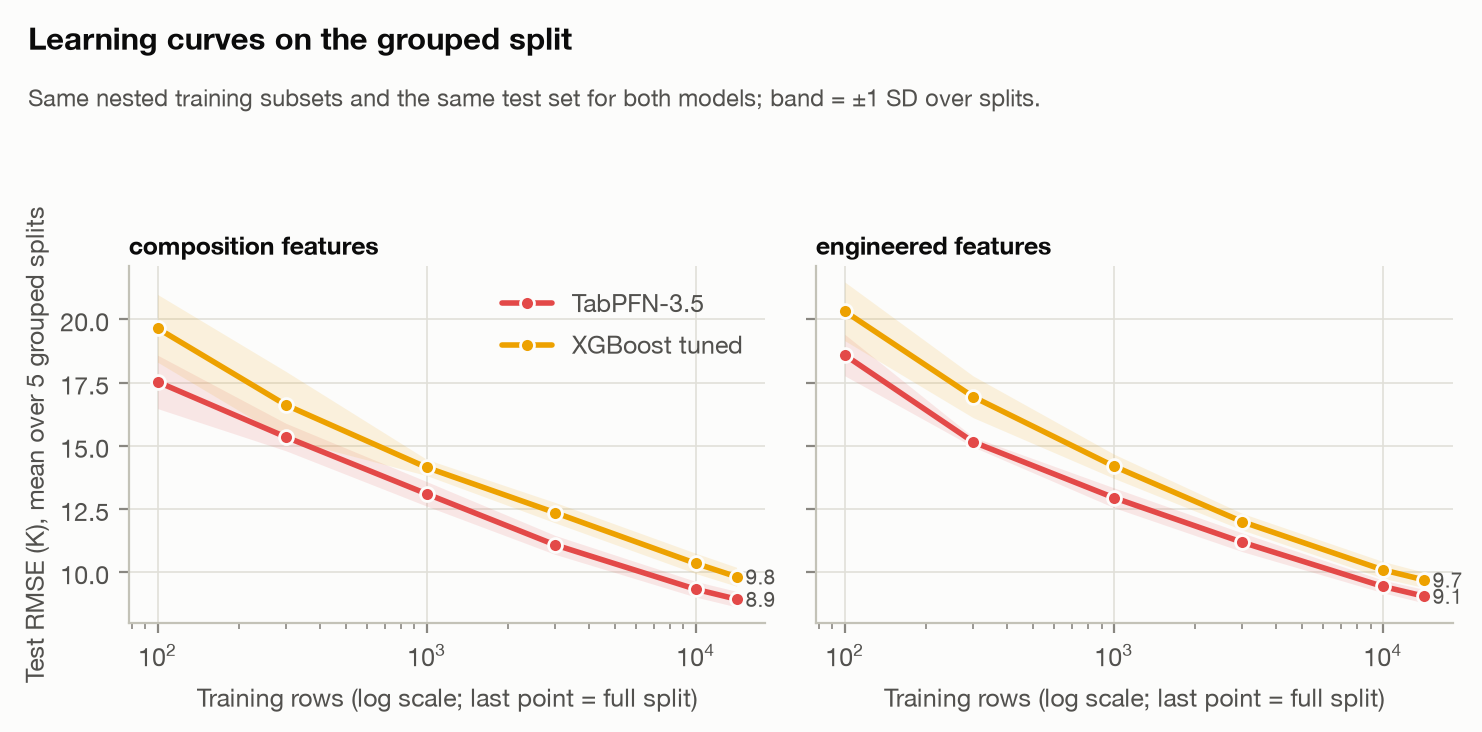

{'uncertainty/conformal': {'jarvis': 56},
 'uncertainty/quantile_regression': {'jarvis': 56},
 'xgb_hamidieh': {'jarvis': 50},
 'xgb_tuned': {'jarvis': 50}}

In [2]:
rmse = curves.pivot_table(index=["features", "model"], columns="n_label", values="rmse")
display(rmse.reindex(columns=SIZES).round(2))
paired = pd.read_csv(LC / "paired.csv", dtype={"n_label": str})
display(paired.round(3))
display(Image(FIG / "learning_curves.png"))
json.loads((LC / "machines.json").read_text())

## 2. Accuracy of the quantile-grid summaries
Exact values from TabPFN's full output vs the committed 107-level grid summaries, 400 rows on
each of two grouped splits.

In [3]:
pd.DataFrame(json.loads((UNC / "quantile_vs_full.json").read_text()))

,split_00,split_01
rows,400,400
mean_full_vs_phase2_K,"{'max': 0.014087677001953125, 'median': 0.0014...","{'max': 0.013263702392578125, 'median': 0.0018..."
crps_exact_vs_grid_K,"{'max': 0.072915209293825, 'median': 0.0009086...","{'max': 0.05198641748945221, 'median': 0.00071..."
crps_mean_exact_vs_grid_K,"[6.178780183602573, 6.179863929748535]","[5.62844178969553, 5.629215240478516]"
pit_exact_vs_grid,"{'max': 0.004795926303685638, 'median': 8.1099...","{'max': 0.004763690004040533, 'median': 7.2070..."
p_above_77K_exact_vs_grid,"{'max': 0.004970759822218618, 'median': 0.0001...","{'max': 0.004957259462738617, 'median': 0.0001..."
p_above_77K_exact_below_grid_floor,72,79
quantiles_exact_vs_grid_K,"{'max': 0.03331413998285626, 'median': 0.00126...","{'max': 0.02862463683074168, 'median': 0.00122..."


## 3. Interval coverage, width and CRPS
Averaged over splits. `crps` uses TabPFN's 100-level grid; `crps20` uses the 20-level grid that
the XGBoost baselines are scored on (TabPFN on the same levels).

In [4]:
cols = [
    "coverage_50%",
    "coverage_80%",
    "coverage_90%",
    "coverage_95%",
    "width_80%",
    "width_95%",
    "crps",
    "crps20",
    "rmse",
]
allrows = cal[(cal.group == "all") & (cal.kind != "leave_family_out")]
allrows.set_index(["kind", "features", "model"])[cols].round(3)

coverage_50%  coverage_80%  \
kind              features    model                                             
random            engineered  tabpfn                      0.538         0.817   
                  composition tabpfn                      0.548         0.829   
grouped           engineered  tabpfn                      0.530         0.813   
                  composition tabpfn                      0.540         0.825   
grouped_no_oxygen engineered  tabpfn                      0.522         0.801   
                  composition tabpfn                      0.537         0.822   
grouped           engineered  quantile_regression         0.427         0.720   
                  composition quantile_regression         0.425         0.701   
                  engineered  conformal                   0.494         0.792   
                  composition conformal                   0.495         0.796   

                                                   coverage_90%  coverage_95%  \
kind              features    model                                             
random            engineered  tabpfn                      0.906         0.952   
                  composition tabpfn                      0.915         0.957   
grouped           engineered  tabpfn                      0.906         0.952   
                  composition tabpfn                      0.915         0.958   
grouped_no_oxygen engineered  tabpfn                      0.897         0.950   
                  composition tabpfn                      0.913         0.957   
grouped           engineered  quantile_regression         0.849         0.932   
                  composition quantile_regression         0.825         0.909   
                  engineered  conformal                   0.897         0.949   
                  composition conformal                   0.896         0.948   

                                                   width_80%  width_95%  \
kind              features    model                                       
random            engineered  tabpfn                  14.485     24.884   
                  composition tabpfn                  15.043     25.693   
grouped           engineered  tabpfn                  15.425     26.422   
                  composition tabpfn                  15.966     27.294   
grouped_no_oxygen engineered  tabpfn                  15.888     27.654   
                  composition tabpfn                  16.800     28.558   
grouped           engineered  quantile_regression     20.914     56.972   
                  composition quantile_regression     17.773     42.474   
                  engineered  conformal               17.256     43.630   
                  composition conformal               17.917     43.996   

                                                    crps  crps20    rmse  
kind              features    model                                       
random            engineered  tabpfn               3.252     NaN   8.713  
                  composition tabpfn               3.281     NaN   8.702  
grouped           engineered  tabpfn               3.445   3.453   9.007  
                  composition tabpfn               3.444   3.451   8.968  
grouped_no_oxygen engineered  tabpfn               4.023     NaN  10.484  
                  composition tabpfn               3.801     NaN   9.929  
grouped           engineered  quantile_regression    NaN   4.585  11.170  
                  composition quantile_regression    NaN   4.543  10.858  
                  engineered  conformal              NaN   4.719  10.071  
                  composition conformal              NaN   4.802  10.209

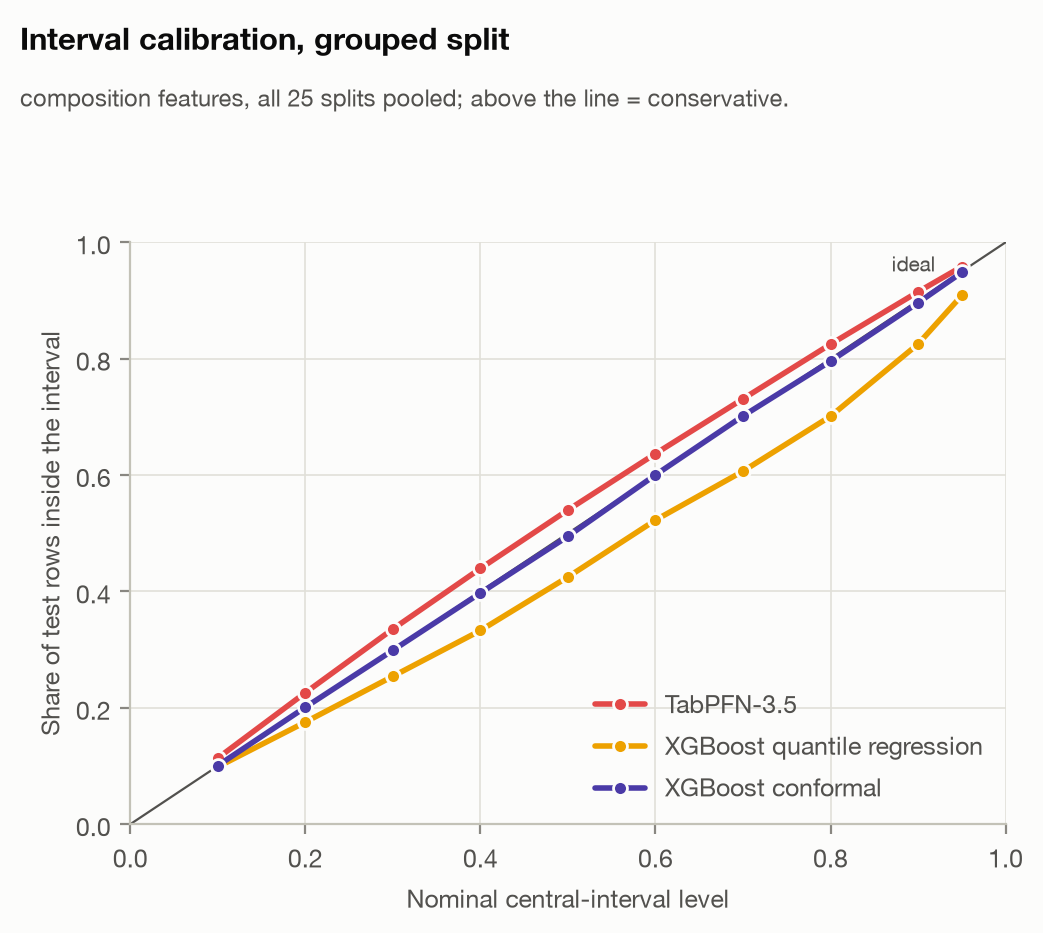

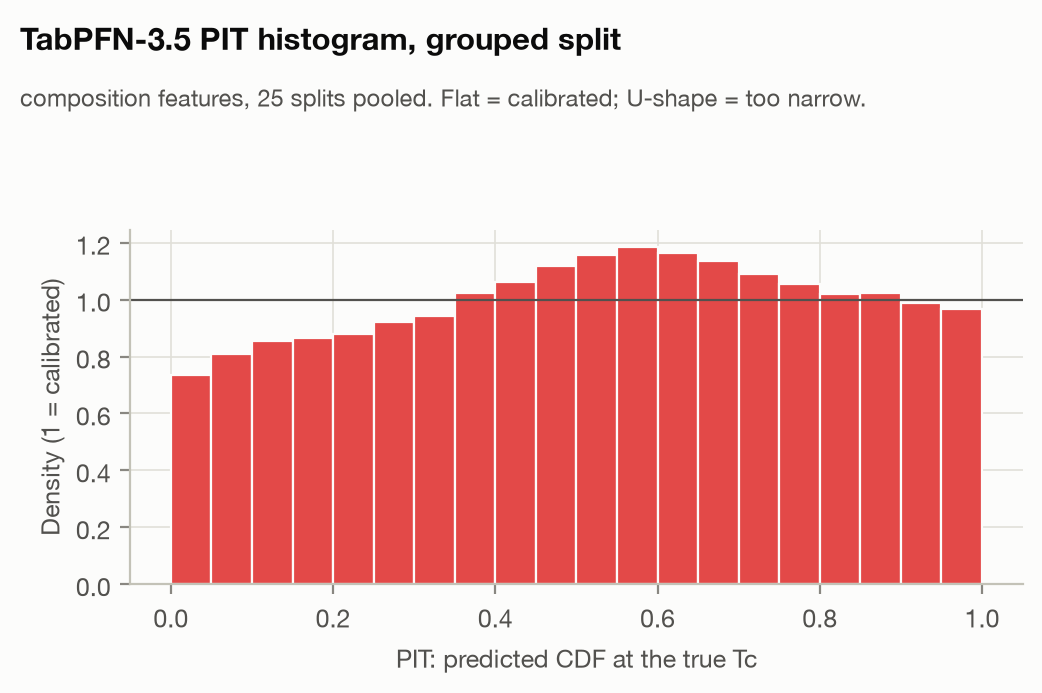

In [5]:
display(Image(FIG / "calibration_curve.png"))
display(Image(FIG / "pit_hist.png"))

## 4. Coverage by Tc band, family and missing-oxygen rows (grouped split)

In [6]:
g = cal[(cal.kind == "grouped") & (cal.features == "composition")]
g.pivot_table(index="group", columns="model", values=["coverage_95%", "width_95%"]).round(3)

coverage_95%                            width_95%  \
model                    conformal quantile_regression tabpfn conformal   
group                                                                     
10-77 K                      0.931               0.941  0.960    43.996   
Tc < 10 K                    0.990               0.893  0.961    43.996   
Tc > 77 K                    0.909               0.860  0.950    43.996   
all                          0.948               0.909  0.958    43.996   
family: cuprate              0.904               0.888  0.956    43.996   
family: iron-based           0.976               0.897  0.954    43.996   
family: other                0.995               0.935  0.962    43.996   
oxygen amount missing        0.874               0.864  0.962    43.996   

                                                   
model                 quantile_regression  tabpfn  
group                                              
10-77 K                            44.387  35.279  
Tc < 10 K                          34.721   9.281  
Tc > 77 K                          53.112  43.122  
all                                42.474  27.294  
family: cuprate                    50.626  42.942  
family: iron-based                 38.268  24.952  
family: other                      33.708   9.391  
oxygen amount missing              52.862  51.242

## 5. Is P(Tc > 77 K) reliable?

,model,kind,features,brier,base_rate_brier
0,tabpfn,random,engineered,0.0355,0.1497
1,tabpfn,random,composition,0.0358,0.1497
2,tabpfn,grouped,engineered,0.0369,0.1500
3,tabpfn,grouped,composition,0.0369,0.1500
4,tabpfn,grouped_no_oxygen,engineered,0.0499,0.1554
5,tabpfn,grouped_no_oxygen,composition,0.0442,0.1554
6,quantile_regression,grouped,engineered,0.0501,0.1500
7,quantile_regression,grouped,composition,0.0503,0.1500
8,conformal,grouped,engineered,0.0495,0.1500
9,conformal,grouped,composition,0.0501,0.1500


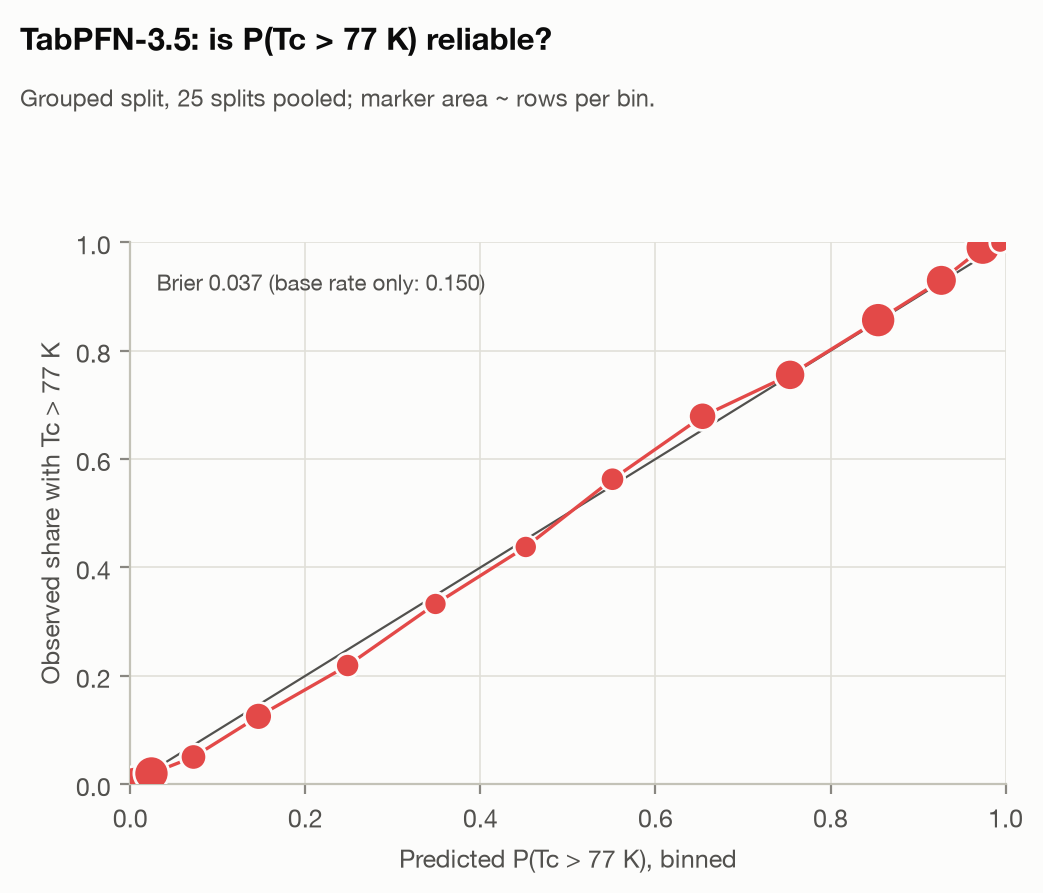

In [7]:
display(pd.read_csv(UNC / "p77_brier.csv").round(4))
display(Image(FIG / "p77_reliability.png"))

## 6. Leave-family-out: do the intervals know when the model is extrapolating?
Coverage and width on each held-out family, next to the same family in-distribution (grouped
split), and the per-row rank correlation between 95% interval width and absolute error.

,model,features,held_out_family,n,held_out_coverage_95%,in_distribution_coverage_95%,held_out_coverage_80%,in_distribution_coverage_80%,held_out_width_95%,in_distribution_width_95%,width_error_spearman
0,tabpfn,engineered,cuprate,10532,0.846,0.949,0.390,0.808,92.849,41.269,0.232
1,tabpfn,engineered,iron-based,1682,0.383,0.954,0.127,0.799,17.520,23.367,0.040
2,tabpfn,engineered,other,9049,0.856,0.955,0.527,0.822,89.865,9.601,0.490
3,tabpfn,composition,cuprate,10532,0.783,0.956,0.358,0.820,89.342,42.942,0.009
4,tabpfn,composition,iron-based,1682,0.598,0.954,0.222,0.805,29.743,24.952,0.078
5,tabpfn,composition,other,9049,0.946,0.962,0.521,0.834,113.243,9.391,0.574
6,quantile_regression,engineered,cuprate,10532,0.351,0.924,0.206,0.713,41.616,62.536,0.295
7,quantile_regression,engineered,iron-based,1682,0.715,0.948,0.065,0.728,26.135,52.873,0.251
8,quantile_regression,engineered,other,9049,0.216,0.940,0.115,0.728,59.803,51.207,0.518
9,quantile_regression,composition,cuprate,10532,0.278,0.888,0.080,0.688,35.988,50.626,0.206


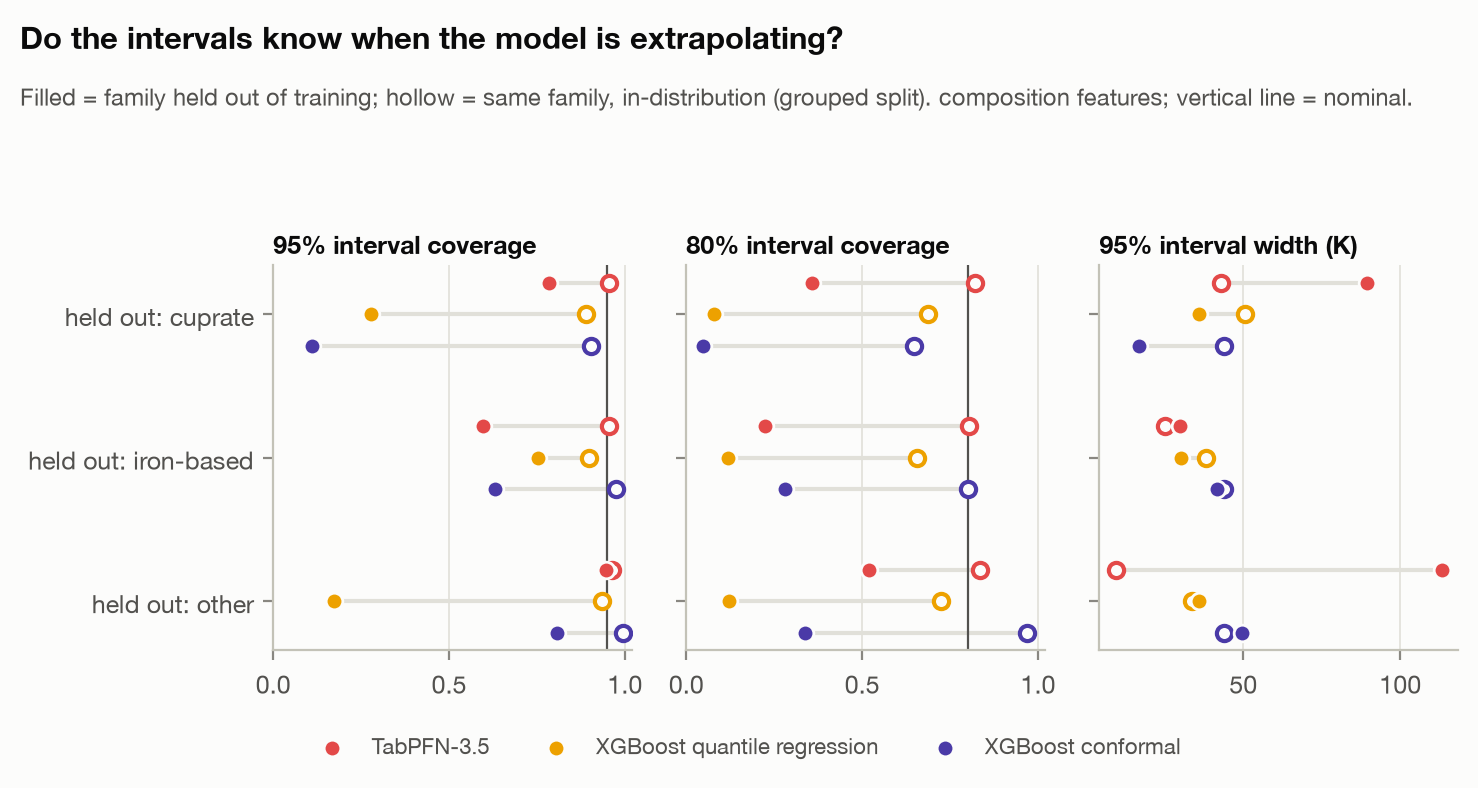

In [8]:
lfo = pd.read_csv(UNC / "lfo.csv")
keep = [
    "model",
    "features",
    "held_out_family",
    "n",
    "held_out_coverage_95%",
    "in_distribution_coverage_95%",
    "held_out_coverage_80%",
    "in_distribution_coverage_80%",
    "held_out_width_95%",
    "in_distribution_width_95%",
    "width_error_spearman",
]
display(lfo[keep].round(3))
display(Image(FIG / "lfo_coverage.png"))